# Mutual Fund Analytics – Performance Analytics

Bluestock Fintech Capstone Project

This notebook evaluates the performance and risk characteristics of 40 mutual fund schemes using historical NAV data and benchmark indices.

Metrics analysed:

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

Objective:
To identify top-performing mutual funds using risk-adjusted performance metrics.

In [2]:
from pathlib import Path

ROOT = Path.cwd().parent

DATA = ROOT / "data" / "processed"

daily_returns = pd.read_csv(DATA / "daily_returns.csv")
cagr = pd.read_csv(DATA / "cagr.csv")
sharpe = pd.read_csv(DATA / "sharpe_ratio.csv")
sortino = pd.read_csv(DATA / "sortino_ratio.csv")
alpha_beta = pd.read_csv(DATA / "alpha_beta.csv")
max_dd = pd.read_csv(DATA / "max_drawdown.csv")
scorecard = pd.read_csv(DATA / "fund_scorecard.csv")

# Daily Returns Analysis

Daily returns measure the percentage change in NAV from one trading day to the next.

Formula:

daily_return = (NAV_t / NAV_t-1) - 1

Daily returns form the basis for all subsequent risk and performance calculations.

In [3]:
daily_returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


# CAGR Analysis

Compound Annual Growth Rate (CAGR) measures the annualised growth rate of a fund over a specified investment horizon.

Higher CAGR indicates stronger long-term performance.

In [4]:
cagr.sort_values(
    "cagr",
    ascending=False
).head(10)

,amfi_code,cagr
25,120505,0.328016
21,119598,0.323981
39,149324,0.322621
36,148569,0.319245
34,148567,0.309499
30,120843,0.308833
2,100033,0.300997
38,149323,0.295581
16,119094,0.281926
19,119551,0.257849


# Sharpe Ratio Analysis

Sharpe Ratio evaluates risk-adjusted returns.

Formula:

Sharpe = (Rp − Rf) / σ

where:

- Rp = portfolio return
- Rf = risk-free rate
- σ = standard deviation

Higher Sharpe ratios indicate better returns per unit of risk.

In [5]:
sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


# Sortino Ratio Analysis

Sortino Ratio is similar to Sharpe Ratio but penalises only downside volatility.

This metric provides a more realistic assessment of investment risk.

In [6]:
sortino.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


# Alpha and Beta Analysis

Alpha measures excess return above benchmark performance.

Beta measures sensitivity to market movements.

Interpretation:

- Alpha > 0 = outperforming benchmark
- Beta > 1 = more volatile than market
- Beta < 1 = less volatile than market

In [7]:
alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


# Maximum Drawdown Analysis

Maximum Drawdown measures the largest peak-to-trough decline experienced by a fund.

Lower drawdowns generally indicate better capital preservation.

In [10]:
max_dd.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


# Fund Scorecard

The Fund Scorecard combines multiple performance indicators into a single score.

Weights:

- 30% CAGR
- 25% Sharpe Ratio
- 20% Alpha
- 15% Expense Ratio
- 10% Maximum Drawdown

This score helps rank funds holistically.

In [11]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
0,120505,0.328016,1.180101,0.293014,-0.017391,-0.181885,1.0,5.0,3.0,25.0,42.066667
1,119598,0.323981,0.945308,0.301114,0.074266,-0.287060,2.0,14.0,1.0,36.0,37.063492
2,148567,0.309499,1.448291,0.271150,-0.028133,-0.112657,5.0,1.0,7.0,8.0,35.107143
3,120843,0.308833,1.306744,0.272784,-0.008737,-0.129740,6.0,2.0,5.0,13.0,22.269231
4,149324,0.322621,0.949796,0.298179,0.132608,-0.311719,3.0,13.0,2.0,37.0,22.193347
5,148569,0.319245,1.234930,0.283473,-0.010201,-0.163967,4.0,3.0,4.0,21.0,21.309524
6,120507,0.072324,0.495723,0.067472,-0.001125,-0.000977,29.0,23.0,31.0,1.0,12.766601
7,119551,0.257849,1.208267,0.232196,-0.056045,-0.150124,10.0,4.0,10.0,17.0,11.838235
8,100033,0.300997,1.093699,0.272343,-0.011200,-0.162172,7.0,7.0,6.0,20.0,11.690476
9,149323,0.295581,1.132122,0.265836,0.003479,-0.172481,8.0,6.0,8.0,22.0,10.871212


# Benchmark Comparison

Mutual fund performance is compared against benchmark indices such as:

- Nifty 50
- Nifty 100

The objective is to determine whether funds generated excess returns relative to the market.

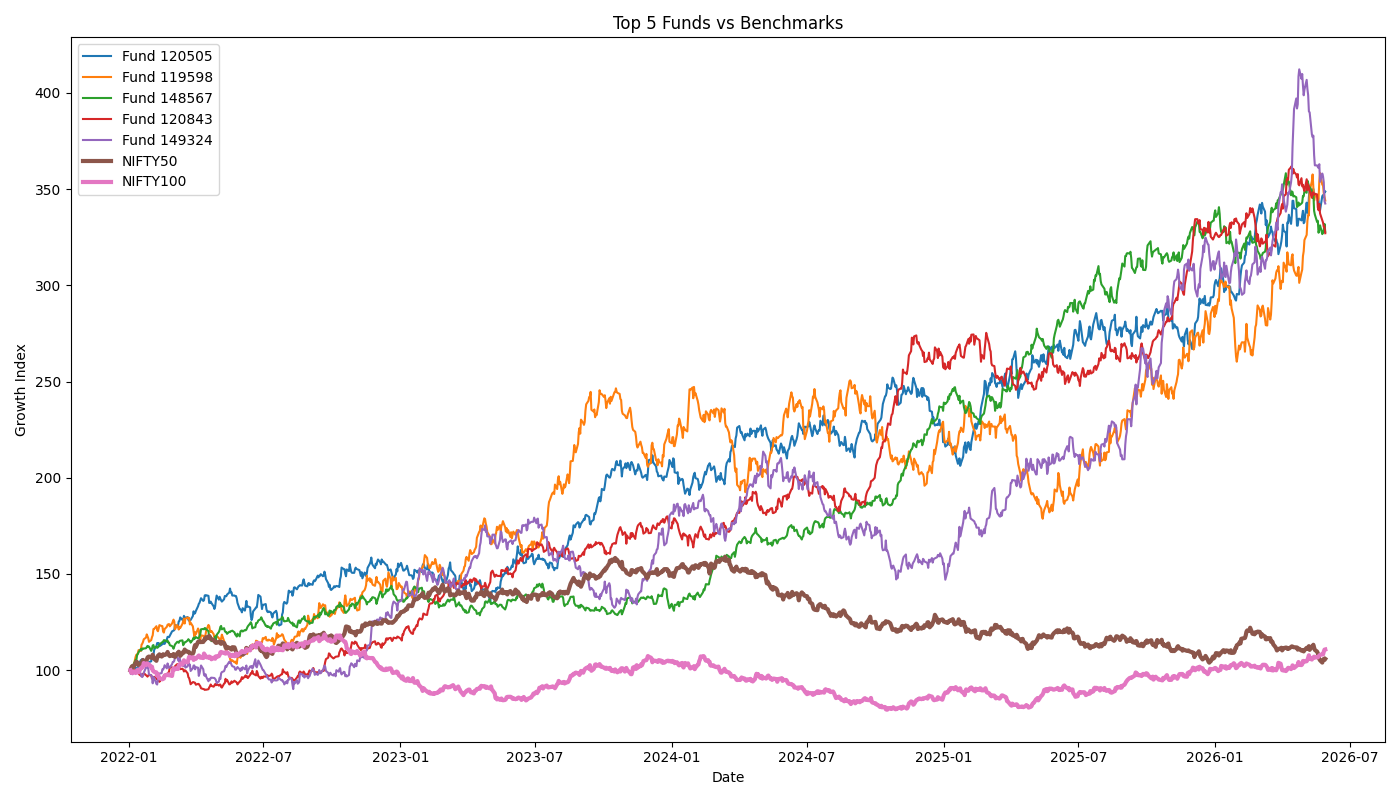

In [13]:
from IPython.display import Image, display

display(
    Image(
        filename="../reports/charts/benchmark_comparison.png"
    )
)

# Key Performance Findings

1. Several funds achieved strong CAGR growth over the study period.

2. Risk-adjusted performance varied significantly across schemes.

3. High Sharpe Ratio funds generally maintained consistent returns.

4. Sortino Ratios indicated better downside protection in selected schemes.

5. Positive Alpha values suggest benchmark outperformance by several funds.

6. Beta values revealed varying sensitivity to market movements.

7. Some funds experienced significantly larger drawdowns during market corrections.

8. Composite scorecards helped identify the strongest overall performers.

9. Benchmark comparison revealed differences between active fund management and index performance.

10. Risk-adjusted metrics provided deeper insights than returns alone.